=== 数据检查 ===
数据集前5行：
   sepal-length  sepal-width  petal-length  petal-width   Class
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

数据类型：
sepal-length    float64
sepal-width     float64
petal-length    float64
petal-width     float64
Class            object
dtype: object

特征矩阵X的形状: (150, 4)
特征矩阵X的数据类型: float64

标准化前X_train样本示例（第一行）: [4.4 2.9 1.4 0.2]
X_train数据类型: float64
数据标准化完成。

=== 模型评估 ===
模型准确率: 0.9333
混淆矩阵：
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93    

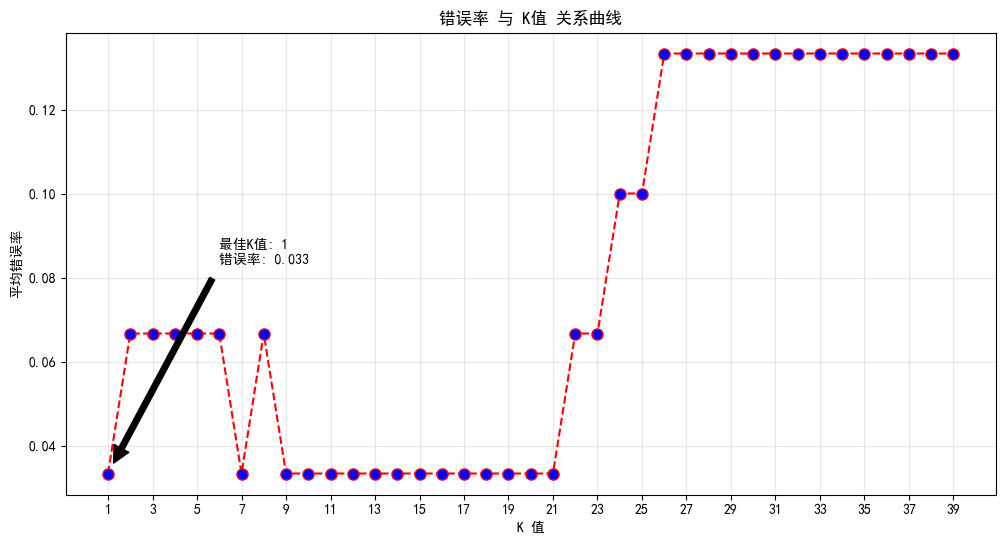

=== 最佳参数 ===
最佳K值: 1
最小错误率: 0.0333
最佳准确率: 0.9667


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. 加载数据并检查  ✅ 修复点在这里
url = "iris_dataset.csv"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']
dataset = pd.read_csv(url, names=names, header=0)  # 加了 header=0

# 关键检查：确保数据已正确加载且为数值型
print("=== 数据检查 ===")
print("数据集前5行：")
print(dataset.head())
print("\n数据类型：")
print(dataset.dtypes)
print("================\n")

# 2. 分离特征和标签
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values

print(f"特征矩阵X的形状: {X.shape}")
print(f"特征矩阵X的数据类型: {X.dtype}")

# 3. 划分训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 4. 数据标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

print(f"\n标准化前X_train样本示例（第一行）: {X_train[0]}")
print(f"X_train数据类型: {X_train.dtype}")

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("数据标准化完成。\n")

# 5. 训练KNN分类器
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train_scaled, y_train)

# 6. 预测和评估
y_pred = classifier.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("=== 模型评估 ===")
print(f"模型准确率: {accuracy_score(y_test, y_pred):.4f}")
print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred))
print("\n分类报告：")
print(classification_report(y_test, y_pred))
print("================\n")

# 7. 寻找最佳K值
error = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error.append(np.mean(pred_i != y_test))

# 8. 绘制错误率曲线
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', 
         marker='o', markerfacecolor='blue', markersize=8)
plt.title('错误率 与 K值 关系曲线')
plt.xlabel('K 值')
plt.ylabel('平均错误率')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 40, 2))

min_error_idx = np.argmin(error)
min_k = min_error_idx + 1
min_error = error[min_error_idx]
plt.annotate(f'最佳K值: {min_k}\n错误率: {min_error:.3f}', 
             xy=(min_k, min_error), 
             xytext=(min_k+5, min_error+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.show()

# 9. 输出最佳K值
print(f"=== 最佳参数 ===")
print(f"最佳K值: {min_k}")
print(f"最小错误率: {min_error:.4f}")
print(f"最佳准确率: {1-min_error:.4f}")
print("================")